In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

In [35]:
# ── Palette & style ────────────────────────────────────────────────────────
BLUE    = "#2563eb"
BLUE_L  = "#93c5fd"
TEAL    = "#0d9488"
TEAL_L  = "#99f6e4"
AMBER   = "#d97706"
GRAY    = "#6b7280"
LGRAY   = "#f3f4f6"
DGRAY   = "#1f2937"

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Palatino Linotype", "Palatino", "Book Antiqua", "DejaVu Serif"],
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     "#d1d5db",
    "axes.labelcolor":    DGRAY,
    "axes.titlecolor":    DGRAY,
    "xtick.color":        GRAY,
    "ytick.color":        GRAY,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "grid.color":         "#e5e7eb",
    "grid.linewidth":     0.7,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
})

In [36]:
pmt_df = pd.read_csv("../results/sp500_summary_results.csv")
pmt_df.head()

,ticker,W_star,h_star,rho_star
0,A,300,60,0.666664
1,AAPL,20,10,0.226246
2,ABBV,60,30,0.245119
3,ABNB,300,60,0.670381
4,ABT,40,15,0.203688


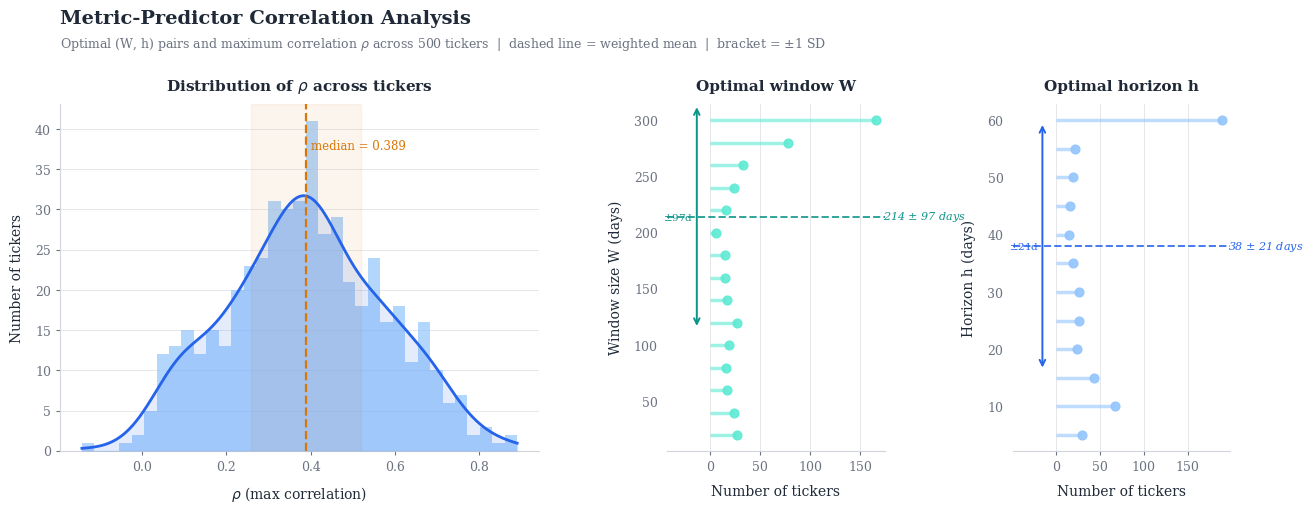

In [37]:
# ── Palette & style ────────────────────────────────────────────────────────
BLUE    = "#2563eb"
BLUE_L  = "#93c5fd"
TEAL    = "#0d9488"
TEAL_L  = "#5eead4"
AMBER   = "#d97706"
GRAY    = "#6b7280"
DGRAY   = "#1f2937"

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Palatino Linotype", "Palatino", "Book Antiqua", "DejaVu Serif"],
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     "#d1d5db",
    "axes.labelcolor":    DGRAY,
    "axes.titlecolor":    DGRAY,
    "xtick.color":        GRAY,
    "ytick.color":        GRAY,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "grid.color":         "#e5e7eb",
    "grid.linewidth":     0.7,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
})

# ── Layout ─────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(13, 5.5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[2.2, 1, 1],
                        wspace=0.42, left=0.07, right=0.97,
                        top=0.78, bottom=0.15)

ax_rho = fig.add_subplot(gs[0])
ax_W   = fig.add_subplot(gs[1])
ax_h   = fig.add_subplot(gs[2])

# ══════════════════════════════════════════════════════════════════════════
# Panel 1 — rho histogram + KDE
# ══════════════════════════════════════════════════════════════════════════
sns.histplot(data=pmt_df, x="rho_star", ax=ax_rho,
             kde=False, color=BLUE_L, alpha=0.7, linewidth=0, bins=35)

vals = pmt_df["rho_star"].dropna().values
kde  = gaussian_kde(vals, bw_method="scott")
xs   = np.linspace(vals.min(), vals.max(), 500)
bin_width = (vals.max() - vals.min()) / 35
ys   = kde(xs) * len(vals) * bin_width

ax_rho.plot(xs, ys, color=BLUE, linewidth=2, zorder=5)
ax_rho.fill_between(xs, ys, alpha=0.12, color=BLUE, zorder=4)

med      = np.median(vals)
q25, q75 = np.percentile(vals, [25, 75])
ymax     = ax_rho.get_ylim()[1]

ax_rho.axvspan(q25, q75, alpha=0.07, color=AMBER, zorder=2)
ax_rho.axvline(med, color=AMBER, linewidth=1.6, linestyle="--", zorder=6)
ax_rho.text(med + 0.012, ymax * 0.90,
            f"median = {med:.3f}", color=AMBER, fontsize=8.5, va="top")

ax_rho.yaxis.grid(True)
ax_rho.set_axisbelow(True)
ax_rho.set_xlabel(r"$\rho$ (max correlation)", fontsize=10, labelpad=8)
ax_rho.set_ylabel("Number of tickers", fontsize=10, labelpad=8)
ax_rho.set_title(r"Distribution of $\rho$ across tickers",
                 fontsize=11, fontweight="bold", pad=10)

# ══════════════════════════════════════════════════════════════════════════
# Helper — horizontal lollipop chart with clean +/- SD annotation
# ══════════════════════════════════════════════════════════════════════════
def lollipop_panel(ax, series, color_bar, color_line, xlabel, ylabel, title):
    counts = series.value_counts().sort_index()
    yv     = counts.index.values.astype(float)
    cv     = counts.values

    wmean = np.average(yv, weights=cv)
    wstd  = np.sqrt(np.average((yv - wmean)**2, weights=cv))

    ax.hlines(yv, 0, cv, color=color_bar, linewidth=2.5, alpha=0.6)
    ax.scatter(cv, yv, color=color_bar, s=40, zorder=5, alpha=0.9)

    x_bracket = -max(cv) * 0.08
    ax.annotate("", xy=(x_bracket, wmean - wstd),
                xytext=(x_bracket, wmean + wstd),
                arrowprops=dict(arrowstyle="<->", color=color_line,
                                lw=1.4, shrinkA=0, shrinkB=0))
    ax.axhline(wmean, color=color_line, linewidth=1.4,
               linestyle="--", zorder=4, alpha=0.85)

    ax.text(max(cv) * 1.04, wmean,
            f"{wmean:.0f} $\\pm$ {wstd:.0f} days",
            color=color_line, fontsize=8, va="center", ha="left", style="italic")

    ax.text(x_bracket - max(cv) * 0.02, wmean,
            f"$\\pm${wstd:.0f}d", color=color_line,
            fontsize=7.5, va="center", ha="right")

    ax.xaxis.grid(True)
    ax.set_axisbelow(True)
    ax.set_xlim(left=x_bracket - max(cv) * 0.18)
    ax.set_xlabel(xlabel, fontsize=10, labelpad=8)
    ax.set_ylabel(ylabel, fontsize=10, labelpad=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%g"))
    ax.spines["left"].set_visible(False)
    ax.tick_params(left=False)

lollipop_panel(ax_W, pmt_df["W_star"],
               color_bar=TEAL_L, color_line=TEAL,
               xlabel="Number of tickers",
               ylabel="Window size W (days)",
               title="Optimal window W")

lollipop_panel(ax_h, pmt_df["h_star"],
               color_bar=BLUE_L, color_line=BLUE,
               xlabel="Number of tickers",
               ylabel="Horizon h (days)",
               title="Optimal horizon h")

# ── Supertitle ─────────────────────────────────────────────────────────────
fig.text(0.07, 0.92,
         "Metric-Predictor Correlation Analysis",
         fontsize=14, fontweight="bold", color=DGRAY, va="bottom")
fig.text(0.07, 0.875,
         f"Optimal (W, h) pairs and maximum correlation $\\rho$ across {len(pmt_df)} tickers"
         f"  |  dashed line = weighted mean  |  bracket = $\\pm$1 SD",
         fontsize=9, color=GRAY, va="bottom")

plt.show()

In [38]:
ar_garch_df = pd.read_csv("../results/garch_summary_results.csv")
ar_garch_df.head()

,ticker,rho_garch
0,A,0.422201
1,AAPL,0.514329
2,ABBV,0.119115
3,ABNB,0.421714
4,ABT,0.304794


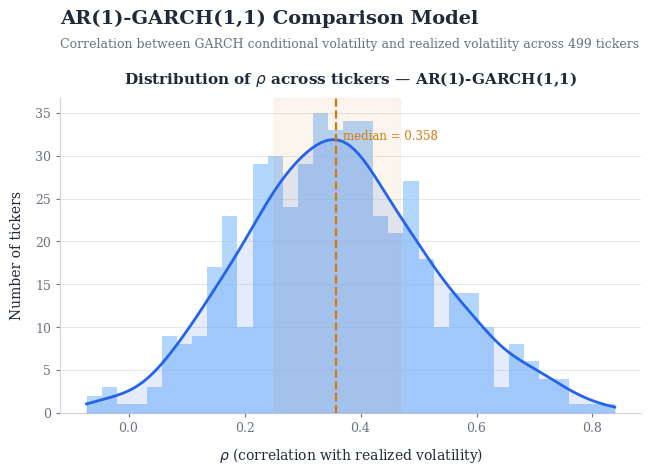

In [39]:
# ── Palette & style ────────────────────────────────────────────────────────
BLUE    = "#2563eb"
BLUE_L  = "#93c5fd"
AMBER   = "#d97706"
GRAY    = "#6b7280"
DGRAY   = "#1f2937"

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Palatino Linotype", "Palatino", "Book Antiqua", "DejaVu Serif"],
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.edgecolor":     "#d1d5db",
    "axes.labelcolor":    DGRAY,
    "axes.titlecolor":    DGRAY,
    "xtick.color":        GRAY,
    "ytick.color":        GRAY,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "grid.color":         "#e5e7eb",
    "grid.linewidth":     0.7,
    "xtick.major.size":   3,
    "ytick.major.size":   3,
})

# ── Layout ─────────────────────────────────────────────────────────────────
fig, ax_rho = plt.subplots(figsize=(7, 5))
fig.subplots_adjust(left=0.12, right=0.95, top=0.78, bottom=0.15)

# ── Histogram + KDE ────────────────────────────────────────────────────────
sns.histplot(data=ar_garch_df, x="rho_garch", ax=ax_rho,
             kde=False, color=BLUE_L, alpha=0.7, linewidth=0, bins=35)

vals = ar_garch_df["rho_garch"].dropna().values
kde  = gaussian_kde(vals, bw_method="scott")
xs   = np.linspace(vals.min(), vals.max(), 500)
bin_width = (vals.max() - vals.min()) / 35
ys   = kde(xs) * len(vals) * bin_width

ax_rho.plot(xs, ys, color=BLUE, linewidth=2, zorder=5)
ax_rho.fill_between(xs, ys, alpha=0.12, color=BLUE, zorder=4)

med      = np.median(vals)
q25, q75 = np.percentile(vals, [25, 75])
ymax     = ax_rho.get_ylim()[1]

ax_rho.axvspan(q25, q75, alpha=0.07, color=AMBER, zorder=2)
ax_rho.axvline(med, color=AMBER, linewidth=1.6, linestyle="--", zorder=6)
ax_rho.text(med + 0.012, ymax * 0.90,
            f"median = {med:.3f}", color=AMBER, fontsize=8.5, va="top")

ax_rho.yaxis.grid(True)
ax_rho.set_axisbelow(True)
ax_rho.set_xlabel(r"$\rho$ (correlation with realized volatility)", fontsize=10, labelpad=8)
ax_rho.set_ylabel("Number of tickers", fontsize=10, labelpad=8)
ax_rho.set_title(r"Distribution of $\rho$ across tickers — AR(1)-GARCH(1,1)",
                 fontsize=11, fontweight="bold", pad=10)

# ── Supertitle ─────────────────────────────────────────────────────────────
fig.text(0.12, 0.92,
         "AR(1)-GARCH(1,1) Comparison Model",
         fontsize=14, fontweight="bold", color=DGRAY, va="bottom")
fig.text(0.12, 0.875,
         f"Correlation between GARCH conditional volatility and realized volatility"
         f" across {len(ar_garch_df)} tickers",
         fontsize=9, color=GRAY, va="bottom")

plt.show()